# Bangkok TMD Rain-Any Neighbor Models (V1)

TMD-station port of `Thailand_Rain_V1.ipynb`. Same 4-model plan, same targets, same
honest-threshold protocol - but trained on **ground-truth rain gauge observations** from
PostgreSQL table `"BKK_TMD_WEATHER_DATA"` instead of Open-Meteo grid forecasts, with the
100 km neighbourhood aggregates joined from `"BKK_TMD_SPATIAL_FEATURES_100KM"`.

Models trained:

- `1h`: LightGBM
- `2h`: LightGBM
- `3h`: HistGradientBoosting
- `6h`: HistGradientBoosting

## Differences from the Open-Meteo notebooks

1. **Source is station observations, not a model grid.** `"BKK_TMD_WEATHER_DATA"` holds
   26 TMD stations around the Bangkok basin (region `1`) at hourly resolution,
   2020-01-01 to 2026-06-24. The label is what a gauge actually measured, so it does not
   inherit any NWP timing bias the way an Open-Meteo-derived label does.
2. **Different variables.** TMD reports `temperature_c`, `pressure_hpa`,
   `humidity_percent`, `wind_speed_avg_knot`, `weather_code`, `visibility_m` - there is no
   `cloud_cover` and no reported `dew_point_2m`. Dew point is estimated from temperature
   and humidity (Magnus formula), and the cloud-cover feature family has no counterpart.
3. **No precompute table, so features are built here.** Lags, rolling precipitation totals,
   pressure tendencies and the four `rain_any_next_Nh` targets are engineered in section 4.
   Only the neighbourhood block is precomputed (`"BKK_TMD_SPATIAL_FEATURES_100KM"`).
4. **Panel is reindexed to a true hourly grid per station.** Coverage is 82% overall, and
   the missing hours are a small number of *long* outages (up to ~6 months) rather than
   scattered single-hour drops - 99.7% of consecutive observations are exactly 1 h apart.
   A plain `.shift(n)` over row order would therefore silently splice a lag or a target
   across a multi-month outage a few hundred times per station. Reindexing onto a complete
   hourly `DatetimeIndex` inserts NaN spacers so every lag is a real clock lag, and the
   affected rows drop out through the non-null filter instead of carrying a wrong value.
5. **Region 2 dropped.** Stations `16` and `19` are region `2` with 799 and 72 rows and no
   coverage in `"BKK_TMD_SPATIAL_FEATURES_100KM"`. They are excluded at the SQL level.
6. **Negative precipitation is nulled, not clipped.** 62 rows carry sentinel values as low
   as -3174 mm. Clipping them to 0 would fabricate a confident "no rain" observation and a
   wrong label, so they become NaN and drop out of both features and targets.
7. **Sparse columns are kept as NaN.** `weather_code` and `visibility_m` are ~32% null.
   Both LightGBM and HistGradientBoosting split on NaN natively, so they are passed
   through rather than imputed or dropped.
8. **HistGradientBoosting early stopping disabled** and **thresholds selected on
   validation**, both carried over from `Thailand_Rain_V1.ipynb` for the same reasons:
   `early_stopping="auto"` builds its holdout with a *random* `train_test_split` (future
   hours leak into the stopping decision), and a threshold picked on test is fitted to the
   rows it is then scored on.

## 1. Setup

In [1]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

pd.set_option("display.max_columns", 180)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

## 2. Configuration

In [2]:
DB_CONFIG = {
    "host": os.getenv("PGHOST", "localhost"),
    "port": int(os.getenv("PGPORT", "5432")),
    "dbname": os.getenv("PGDATABASE", "postgres"),
    "user": os.getenv("PGUSER", "postgres"),
    "password": os.getenv("PGPASSWORD", "Pass1234"),
}

TABLE_NAME = '"BKK_TMD_WEATHER_DATA"'
SPATIAL_TABLE_NAME = '"BKK_TMD_SPATIAL_FEATURES_100KM"'
KEEP_REGION = "1"  # region 2 has 2 stations / 871 rows and no spatial-feature coverage

PROJECT_ROOT = Path.cwd()
MODEL_DIR = PROJECT_ROOT / "ML_Model_V2" / "trained_models" / "tmd_bkk_rain_any_final_4_neighbor_models"

HORIZONS = [1, 2, 3, 6]
RAIN_THRESHOLD_MM = 0.1
PROBABILITY_THRESHOLDS_TO_TEST = np.arange(0.10, 0.91, 0.05)

# Operating thresholds carried over from the Bangkok Open-Meteo notebook, comparison only.
BANGKOK_PROBABILITY_THRESHOLDS = {
    1: 0.60,
    2: 0.50,
    3: 0.30,
    6: 0.30,
}
MODEL_PLAN = {
    1: "lightgbm",
    2: "lightgbm",
    3: "hist_gradient_boosting",
    6: "hist_gradient_boosting",
}

TRAIN_FRACTION = 0.70
VALIDATION_FRACTION = 0.15
SAMPLE_STATIONS = None  # Example for quick smoke tests: 6
RANDOM_STATE = 42

## 3. Feature Columns

In [3]:
# --- station observations, as reported by TMD ---------------------------------
STATION_FEATURE_COLUMNS = [
    "latitude", "longitude", "altitude_m",
    "temperature_c", "precipitation_mm", "pressure_hpa", "humidity_percent",
    "wind_speed_avg_knot", "max_wind_speed_knot",
    # ~32% null; passed through as NaN because both learners split on NaN natively.
    "weather_code", "visibility_m",
]

# --- derived in section 4 -----------------------------------------------------
# No cloud_cover in TMD, so the Open-Meteo cloud-cover family has no counterpart here,
# and dew point is estimated from temperature + humidity rather than reported.
DERIVED_FEATURE_COLUMNS = [
    "wind_dir_avg_sin", "wind_dir_avg_cos", "max_wind_dir_sin", "max_wind_dir_cos",
    "temperature_humidity_index", "temperature_dew_point_spread_est",
    "pressure_hpa_change_3h", "pressure_hpa_change_6h", "humidity_change_3h",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
]

LAG_FEATURE_COLUMNS = [
    "precipitation_lag_1h", "precipitation_lag_2h", "precipitation_lag_3h", "precipitation_lag_6h",
    "precipitation_sum_past_3h", "precipitation_sum_past_6h",
    "precipitation_sum_past_12h", "precipitation_sum_past_24h",
    "temperature_lag_1h", "temperature_lag_3h",
    "humidity_lag_1h", "humidity_lag_3h",
    "pressure_lag_1h", "pressure_lag_3h",
    "wind_speed_lag_1h", "wind_speed_lag_3h",
]

# --- precomputed 100 km neighbourhood block, joined from the spatial table ------
SPATIAL_TABLE_COLUMNS = [
    "nearest_station_distance_km",
    "nearby_station_count_50km", "nearby_station_count_100km", "nearby_station_count_200km",
    "nearby_precip_mean_now_100km", "nearby_precip_max_now_100km",
    "nearby_rain_rate_now_010mm_100km", "nearby_rain_rate_now_025mm_100km",
    "nearby_humidity_mean_now_100km", "nearby_pressure_mean_now_100km",
    "nearby_wind_speed_mean_now_100km",
    "nearby_precip_mean_lag1_100km", "nearby_precip_max_lag1_100km",
    "nearby_rain_rate_lag1_010mm_100km", "nearby_rain_rate_lag1_025mm_100km",
    "nearby_humidity_mean_lag1_100km", "nearby_pressure_mean_lag1_100km",
    "nearby_wind_speed_mean_lag1_100km",
    # ~80-85% null, but the missingness is the signal: NULL means no neighbour within
    # 100 km was raining last hour. Left as NaN so the split itself carries that meaning.
    "nearest_rainy_station_distance_lag1_010mm_km",
    "nearest_rainy_station_distance_lag1_025mm_km",
]

# centre-relative contrasts, derived in section 4
NEIGHBOR_CONTRAST_COLUMNS = [
    "nearby_precip_mean_now_minus_center",
    "nearby_humidity_mean_now_minus_center",
    "center_pressure_minus_nearby_mean",
]

NEIGHBOR_FEATURE_COLUMNS = SPATIAL_TABLE_COLUMNS + NEIGHBOR_CONTRAST_COLUMNS

FEATURE_COLUMNS = (
    STATION_FEATURE_COLUMNS + DERIVED_FEATURE_COLUMNS
    + LAG_FEATURE_COLUMNS + NEIGHBOR_FEATURE_COLUMNS
)
TARGET_COLUMNS = [f"rain_any_next_{horizon}h" for horizon in HORIZONS]

# Mirrors ROW_FILTER_SQL in the Thailand notebook: the deepest member of each feature
# family must be present, so a row that survives has a genuinely complete history.
# weather_code / visibility_m are deliberately absent - they are allowed to stay NaN.
REQUIRED_NON_NULL_COLUMNS = [
    "temperature_c", "precipitation_mm", "pressure_hpa", "humidity_percent",
    "pressure_hpa_change_6h", "precipitation_lag_6h", "precipitation_sum_past_24h",
    "humidity_lag_3h", "wind_speed_lag_3h", "nearby_precip_mean_lag1_100km",
    f"rain_any_next_{max(HORIZONS)}h",
]

print(f"Features used: {len(FEATURE_COLUMNS)}")
print(f"  station observations : {len(STATION_FEATURE_COLUMNS)}")
print(f"  derived              : {len(DERIVED_FEATURE_COLUMNS)}")
print(f"  lag / rolling        : {len(LAG_FEATURE_COLUMNS)}")
print(f"  neighbourhood 100 km : {len(NEIGHBOR_FEATURE_COLUMNS)}")
print(f"Targets: {TARGET_COLUMNS}")

Features used: 63
  station observations : 11
  derived              : 13
  lag / rolling        : 16
  neighbourhood 100 km : 23
Targets: ['rain_any_next_1h', 'rain_any_next_2h', 'rain_any_next_3h', 'rain_any_next_6h']


## 4. Load And Engineer TMD Training Data

The Thailand notebook streams a ready-made precompute table. There is no TMD equivalent,
so the panel is assembled here: observations join their precomputed 100 km neighbourhood
block in SQL, then the panel is reindexed onto a complete hourly grid per station before
any `shift` / `rolling` runs. At ~1.2M rows x 63 features the float32 matrix is well under
half a GB, so the streaming server-side cursor from the Thailand version is unnecessary -
but the float32 dtype and the zero-copy chronological views in section 6 are kept.

In [4]:
def connect():
    return psycopg2.connect(**DB_CONFIG)


def read_raw_tmd_data(sample_stations=None):
    """Observations LEFT JOINed to their precomputed 100 km neighbourhood features."""
    neighbor_sql = ",\n        ".join(f"spatial.{c}" for c in SPATIAL_TABLE_COLUMNS)
    query = f"""
    SELECT
        weather.utc_time,
        weather.station,
        weather.station_name,
        weather.latitude,
        weather.longitude,
        weather.altitude_m,
        weather.wind_dir_avg_deg,
        weather.max_wind_dir_deg,
        weather.wind_speed_avg_knot,
        weather.max_wind_speed_knot,
        weather.temperature_c,
        -- 62 rows carry sentinel values down to -3174 mm. NULL them rather than clip to 0:
        -- clipping would invent a confident dry observation and a wrong rain_any label.
        CASE WHEN weather.precipitation_mm >= 0 THEN weather.precipitation_mm END AS precipitation_mm,
        weather.pressure_hpa,
        weather.humidity_percent,
        weather.weather_code,
        weather.visibility_m,
        {neighbor_sql}
    FROM {TABLE_NAME} weather
    LEFT JOIN {SPATIAL_TABLE_NAME} spatial
      ON spatial.station = weather.station
     AND spatial.utc_time = weather.utc_time
    WHERE weather.utc_time IS NOT NULL
      AND weather.station IS NOT NULL
      AND weather.latitude IS NOT NULL
      AND weather.longitude IS NOT NULL
      AND weather.region = %(region)s
    ORDER BY weather.station, weather.utc_time
    """
    with connect() as conn:
        raw = pd.read_sql_query(query, conn, params={"region": KEEP_REGION},
                                parse_dates=["utc_time"])
    if sample_stations:
        keep = sorted(raw["station"].unique())[:sample_stations]
        raw = raw[raw["station"].isin(keep)].reset_index(drop=True)
    return raw


def to_hourly_panel(raw):
    """Reindex each station onto a gap-free hourly DatetimeIndex.

    TMD coverage is 82%, and the holes are a few hundred *long* outages per station rather
    than scattered single hours. Without this, the row-order `shift(6)` behind
    `precipitation_lag_6h` would happily reach across a six-month outage. The inserted rows
    are all-NaN spacers; they never reach the model because the non-null filter drops them,
    but they force every lag to be a real clock lag.
    """
    static_columns = ["station_name", "latitude", "longitude", "altitude_m"]
    frames = []
    for station_id, group in raw.groupby("station", sort=True):
        group = group.drop_duplicates("utc_time").set_index("utc_time").sort_index()
        full_index = pd.date_range(group.index.min(), group.index.max(), freq="h")
        group = group.reindex(full_index)
        group.index.name = "forecast_time"
        group["station"] = station_id
        # Station identity/geometry is time-invariant, so it is safe to carry into spacers.
        group[static_columns] = group[static_columns].ffill().bfill()
        frames.append(group.reset_index())
    return pd.concat(frames, ignore_index=True)


def angular_sin(series):
    return np.sin(np.deg2rad(series.astype("float64")))


def angular_cos(series):
    return np.cos(np.deg2rad(series.astype("float64")))


def estimate_dew_point_c(temperature_c, humidity_percent):
    """Magnus-Tetens dew point. TMD does not report dew point directly."""
    humidity = humidity_percent.clip(lower=1, upper=100)
    alpha = np.log(humidity / 100.0) + (17.625 * temperature_c) / (243.04 + temperature_c)
    return (243.04 * alpha) / (17.625 - alpha)


def add_derived_features(data):
    data["wind_dir_avg_sin"] = angular_sin(data["wind_dir_avg_deg"])
    data["wind_dir_avg_cos"] = angular_cos(data["wind_dir_avg_deg"])
    data["max_wind_dir_sin"] = angular_sin(data["max_wind_dir_deg"])
    data["max_wind_dir_cos"] = angular_cos(data["max_wind_dir_deg"])
    data["temperature_humidity_index"] = data["temperature_c"] * (data["humidity_percent"] / 100.0)
    dew_point = estimate_dew_point_c(data["temperature_c"], data["humidity_percent"])
    data["temperature_dew_point_spread_est"] = data["temperature_c"] - dew_point

    hour = data["forecast_time"].dt.hour
    month = data["forecast_time"].dt.month
    data["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    data["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    data["month_sin"] = np.sin(2 * np.pi * month / 12)
    data["month_cos"] = np.cos(2 * np.pi * month / 12)

    # Centre-relative contrasts against the precomputed neighbourhood means.
    data["nearby_precip_mean_now_minus_center"] = (
        data["nearby_precip_mean_now_100km"] - data["precipitation_mm"])
    data["nearby_humidity_mean_now_minus_center"] = (
        data["nearby_humidity_mean_now_100km"] - data["humidity_percent"])
    data["center_pressure_minus_nearby_mean"] = (
        data["pressure_hpa"] - data["nearby_pressure_mean_now_100km"])
    return data


def add_lag_features(data):
    """Backward-looking features. Shifting by rows is safe because the panel is gap-free."""
    grouped = data.groupby("station", group_keys=False)

    data["pressure_hpa_change_3h"] = grouped["pressure_hpa"].diff(3)
    data["pressure_hpa_change_6h"] = grouped["pressure_hpa"].diff(6)
    data["humidity_change_3h"] = grouped["humidity_percent"].diff(3)

    lag_specs = {
        "precipitation_lag_1h": ("precipitation_mm", 1),
        "precipitation_lag_2h": ("precipitation_mm", 2),
        "precipitation_lag_3h": ("precipitation_mm", 3),
        "precipitation_lag_6h": ("precipitation_mm", 6),
        "temperature_lag_1h": ("temperature_c", 1),
        "temperature_lag_3h": ("temperature_c", 3),
        "humidity_lag_1h": ("humidity_percent", 1),
        "humidity_lag_3h": ("humidity_percent", 3),
        "pressure_lag_1h": ("pressure_hpa", 1),
        "pressure_lag_3h": ("pressure_hpa", 3),
        "wind_speed_lag_1h": ("wind_speed_avg_knot", 1),
        "wind_speed_lag_3h": ("wind_speed_avg_knot", 3),
    }
    for output_column, (source_column, lag) in lag_specs.items():
        data[output_column] = grouped[source_column].shift(lag)

    # min_periods == window, so a rolling total spanning an outage stays NaN instead of
    # silently under-counting the hours it could not see.
    for hours in [3, 6, 12, 24]:
        data[f"precipitation_sum_past_{hours}h"] = grouped["precipitation_mm"].transform(
            lambda s, window=hours: s.shift(1).rolling(window, min_periods=window).sum()
        )
    return data


def add_targets(data):
    """rain_any_next_Nh: did the station gauge record >= RAIN_THRESHOLD_MM in any of the
    next N hours. NaN whenever any hour of that window is unobserved."""

    def future_rain_any(series, window):
        future_max = (
            series.shift(-1).rolling(window, min_periods=window).max().shift(-(window - 1))
        )
        return pd.Series(
            np.where(future_max.notna(), (future_max >= RAIN_THRESHOLD_MM).astype("float"), np.nan),
            index=series.index,
        )

    grouped = data.groupby("station", group_keys=False)
    for horizon in HORIZONS:
        data[f"rain_any_next_{horizon}h"] = grouped["precipitation_mm"].transform(
            lambda s, window=horizon: future_rain_any(s, window)
        )
    return data


def read_training_data(sample_stations=None):
    raw = read_raw_tmd_data(sample_stations)
    print(f"raw observations : {len(raw):,} rows, {raw['station'].nunique()} stations")

    panel = to_hourly_panel(raw)
    inserted = len(panel) - len(raw)
    print(f"hourly panel     : {len(panel):,} rows "
          f"({inserted:,} NaN spacers inserted for missing hours, "
          f"{inserted / len(panel):.1%} of the grid)")

    panel = add_derived_features(panel)
    panel = add_lag_features(panel)
    panel = add_targets(panel)

    complete = panel.dropna(subset=REQUIRED_NON_NULL_COLUMNS).copy()
    complete = complete[complete["nearby_station_count_100km"] > 0]
    complete[TARGET_COLUMNS] = complete[TARGET_COLUMNS].astype("int8")
    complete = complete.sort_values(["forecast_time", "station"]).reset_index(drop=True)
    print(f"modelling rows   : {len(complete):,} "
          f"({len(complete) / len(panel):.1%} of the hourly grid survive the non-null filter)")
    # The gap-free panel is returned too - section 4b checks the labels against it, and it
    # is the only place the unfiltered hourly gauge series still exists.
    return complete, panel

In [5]:
model_df, hourly_panel = read_training_data(SAMPLE_STATIONS)

x_all = np.ascontiguousarray(model_df[FEATURE_COLUMNS].to_numpy(dtype="float32"))
y_all = model_df[TARGET_COLUMNS].to_numpy(dtype="int8")
forecast_time = model_df["forecast_time"].to_numpy(dtype="datetime64[s]")
station = model_df["station"].to_numpy()

print(f"\nx: {x_all.shape}  y: {y_all.shape}")
print(f"{forecast_time.min()} to {forecast_time.max()}")
print(f"stations: {np.unique(station).size}")
print(f"x memory: {x_all.nbytes / 1e9:.2f} GB")

nan_counts = np.isnan(x_all).sum(axis=0)
if nan_counts.any():
    print("\nRemaining NaNs (passed to the model as-is):")
    display(pd.Series(nan_counts, index=FEATURE_COLUMNS)
            .loc[lambda s: s > 0].sort_values(ascending=False)
            .to_frame("nan_rows").assign(nan_share=lambda d: d["nan_rows"] / len(x_all)))
else:
    print("No NaNs in feature matrix.")

display(model_df[["forecast_time", "station", "precipitation_mm",
                  "nearby_precip_mean_now_100km", *TARGET_COLUMNS]].head())

C:\Users\Brandon\AppData\Local\Temp\ipykernel_31948\2706810320.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  raw = pd.read_sql_query(query, conn, params={"region": KEEP_REGION},


raw observations : 1,005,080 rows, 26 stations


hourly panel     : 1,225,594 rows (220,514 NaN spacers inserted for missing hours, 18.0% of the grid)


modelling rows   : 902,356 (73.6% of the hourly grid survive the non-null filter)



x: (902356, 63)  y: (902356, 4)
2020-01-02T01:00:00 to 2026-06-24T03:00:00


stations: 26
x memory: 0.23 GB

Remaining NaNs (passed to the model as-is):


,nan_rows,nan_share
nearest_rainy_station_distance_lag1_025mm_km,789152,0.8745
nearest_rainy_station_distance_lag1_010mm_km,741896,0.8222
visibility_m,285475,0.3164
weather_code,284379,0.3152
max_wind_dir_cos,2830,0.0031
max_wind_dir_sin,2830,0.0031
wind_dir_avg_sin,2720,0.0030
wind_dir_avg_cos,2720,0.0030
humidity_lag_1h,379,0.0004
max_wind_speed_knot,261,0.0003


,forecast_time,station,precipitation_mm,nearby_precip_mean_now_100km,rain_any_next_1h,rain_any_next_2h,rain_any_next_3h,rain_any_next_6h
0,2020-01-02 01:00:00,21,0.0000,0.0000,0,0,0,0
1,2020-01-02 01:00:00,22,0.0000,0.0000,0,0,0,0
2,2020-01-02 01:00:00,23,0.0000,0.0000,0,0,0,0
3,2020-01-02 01:00:00,24,0.0000,0.0000,0,0,0,0
4,2020-01-02 01:00:00,25,0.0000,0.0000,0,0,0,0


### 4b. Panel Sanity Checks

Three things that would quietly poison the run if they were wrong: every lag must be a
true clock lag, the label must agree with the raw gauge, and stations must not enter or
leave mid-panel in a way that makes the test split describe different geography than train.

lag integrity: 3,183 surviving rows sit just after an outage gap.
              (their own lag columns were NaN, so only later rows remain here)

label check (station 1030): rain_any_next_3h matches a direct recompute off the raw gauge on 100.0000% of 19,363 rows


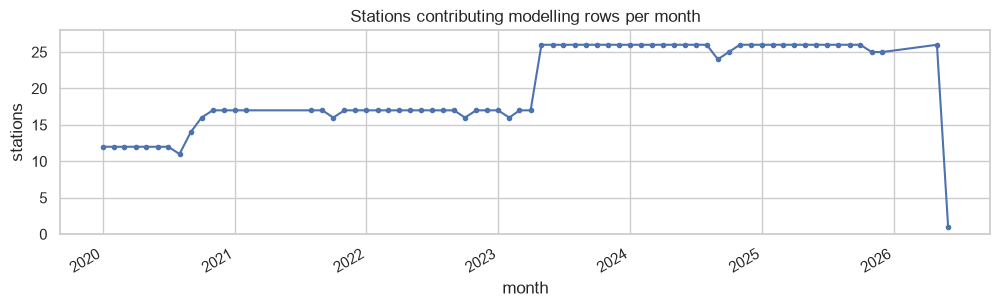

In [6]:
# 1. every surviving row's previous panel row is exactly 1 h back
check = model_df.sort_values(["station", "forecast_time"])
hours_since_previous = (
    check.groupby("station")["forecast_time"].diff().dt.total_seconds() / 3600
)
breaks = int((hours_since_previous.dropna() != 1).sum())
print(f"lag integrity: {breaks:,} surviving rows sit just after an outage gap.")
print("              (their own lag columns were NaN, so only later rows remain here)")

# 2. label agrees with a direct recompute straight off the raw gauge series.
#    The recompute runs on the *unfiltered* hourly series for one station - recomputing on
#    model_df alone would compare against rows that are no longer hourly-contiguous and
#    manufacture disagreements at every outage boundary.
first_station = check["station"].iloc[0]
gauge = (
    hourly_panel[hourly_panel["station"] == first_station]
    .set_index("forecast_time")["precipitation_mm"]
    .sort_index()
)
recomputed = (
    gauge.shift(-1).rolling(3, min_periods=3).max().shift(-2) >= RAIN_THRESHOLD_MM
).astype("float")

spot = check[check["station"] == first_station].set_index("forecast_time")
aligned = recomputed.reindex(spot.index)
agreement = (aligned == spot["rain_any_next_3h"]).mean()
print(f"\nlabel check (station {first_station}): rain_any_next_3h matches a direct recompute "
      f"off the raw gauge on {agreement:.4%} of {len(spot):,} rows")

# 3. station coverage over time - a station that stops reporting before the test window
#    would make train and test describe different geography
coverage = (
    model_df.assign(month=model_df["forecast_time"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")["station"].nunique()
)
coverage.plot(marker=".", figsize=(12, 3))
plt.title("Stations contributing modelling rows per month")
plt.ylabel("stations")
plt.ylim(0, coverage.max() + 2)
plt.show()

## 5. Target Balance

,horizon_h,target_column,rain_threshold_mm,rows,rain_rows,rain_rate
0,1,rain_any_next_1h,0.1000,902356,46536,0.0516
1,2,rain_any_next_2h,0.1000,902356,67764,0.0751
2,3,rain_any_next_3h,0.1000,902356,85591,0.0949
3,6,rain_any_next_6h,0.1000,902356,129948,0.1440


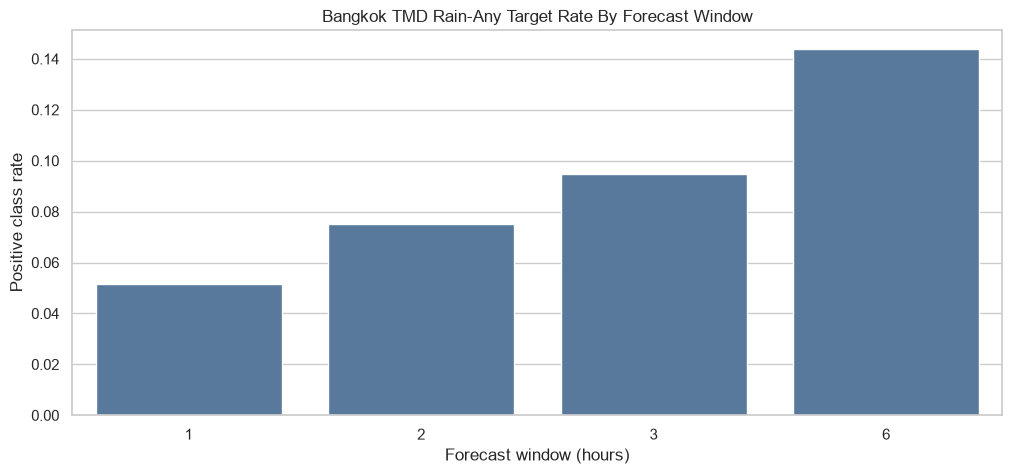

In [7]:
target_balance = pd.DataFrame([
    {
        "horizon_h": horizon,
        "target_column": f"rain_any_next_{horizon}h",
        "rain_threshold_mm": RAIN_THRESHOLD_MM,
        "rows": int(y_all.shape[0]),
        "rain_rows": int(y_all[:, i].sum()),
        "rain_rate": float(y_all[:, i].mean()),
    }
    for i, horizon in enumerate(HORIZONS)
])
display(target_balance)

sns.barplot(data=target_balance, x="horizon_h", y="rain_rate", color="#4c78a8")
plt.title("Bangkok TMD Rain-Any Target Rate By Forecast Window")
plt.xlabel("Forecast window (hours)")
plt.ylabel("Positive class rate")
plt.show()

## 6. Chronological Split

Rows are already ordered by `forecast_time`, so each split is a contiguous slice.
`np.searchsorted` finds the boundaries and the splits are numpy **views** - no data is copied.

In [8]:
def time_split_bounds(times, train_fraction=0.70, validation_fraction=0.15):
    unique_times = np.unique(times)
    train_end = unique_times[int(len(unique_times) * train_fraction)]
    validation_end = unique_times[int(len(unique_times) * (train_fraction + validation_fraction))]
    train_stop = int(np.searchsorted(times, train_end, side="left"))
    validation_stop = int(np.searchsorted(times, validation_end, side="left"))
    return train_end, validation_end, train_stop, validation_stop


train_end, validation_end, train_stop, validation_stop = time_split_bounds(
    forecast_time, TRAIN_FRACTION, VALIDATION_FRACTION
)
print(f"Train before: {train_end}")
print(f"Validation before: {validation_end}")

x_train, x_validation, x_test = x_all[:train_stop], x_all[train_stop:validation_stop], x_all[validation_stop:]
y_train_all, y_validation_all, y_test_all = y_all[:train_stop], y_all[train_stop:validation_stop], y_all[validation_stop:]

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(x_train), "stations": np.unique(station[:train_stop]).size,
     "from": str(forecast_time[:train_stop].min()), "to": str(forecast_time[:train_stop].max())},
    {"split": "validation", "rows": len(x_validation),
     "stations": np.unique(station[train_stop:validation_stop]).size,
     "from": str(forecast_time[train_stop:validation_stop].min()),
     "to": str(forecast_time[train_stop:validation_stop].max())},
    {"split": "test", "rows": len(x_test), "stations": np.unique(station[validation_stop:]).size,
     "from": str(forecast_time[validation_stop:].min()), "to": str(forecast_time[validation_stop:].max())},
])
display(split_summary)
print(f"splits are zero-copy views: {x_train.base is x_all and x_test.base is x_all}")

Train before: 2024-05-26T19:00:00
Validation before: 2025-03-29T20:00:00


,split,rows,stations,from,to
0,train,556560,26,2020-01-02T01:00:00,2024-05-26T18:00:00
1,validation,174206,26,2024-05-26T19:00:00,2025-03-29T19:00:00
2,test,171590,26,2025-03-29T20:00:00,2026-06-24T03:00:00


splits are zero-copy views: True


## 7. Evaluation Helpers

In [9]:
def threshold_metrics(y_true, probabilities, thresholds=PROBABILITY_THRESHOLDS_TO_TEST):
    rows = []
    for threshold in thresholds:
        y_pred = (probabilities >= threshold).astype("int8")
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        rows.append({
            "probability_threshold": float(threshold),
            "predicted_rain_rate": float(y_pred.mean()),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "true_negatives": int(tn),
            "false_positives": int(fp),
            "false_negatives": int(fn),
            "true_positives": int(tp),
        })
    return pd.DataFrame(rows)


def evaluate_probabilities(y_true, probabilities, model_name, horizon, split):
    base = {
        "model": model_name,
        "feature_set": "tmd_station_neighbor_100km",
        "horizon_h": horizon,
        "split": split,
        "rows": int(len(y_true)),
        "rain_rate": float(np.mean(y_true)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
    }
    threshold_df = threshold_metrics(y_true, probabilities)
    for key, value in base.items():
        threshold_df[key] = value
    return base, threshold_df


def best_thresholds(threshold_results):
    return (
        threshold_results.sort_values(["model", "horizon_h", "split", "f1"], ascending=[True, True, True, False])
        .groupby(["model", "horizon_h", "split"], as_index=False)
        .head(1)
        .sort_values(["model", "horizon_h", "split"])
    )


def metrics_at_thresholds(threshold_results, chosen_thresholds, split="test"):
    """Look up metrics at a given operating threshold per horizon."""
    rows = []
    for horizon, threshold in chosen_thresholds.items():
        selected = threshold_results[
            (threshold_results["horizon_h"] == horizon)
            & (threshold_results["model"] == MODEL_PLAN[horizon])
            & (threshold_results["split"] == split)
            & (threshold_results["probability_threshold"].round(10) == round(threshold, 10))
        ]
        rows.append(selected)
    return pd.concat(rows, ignore_index=True)

## 8. Train Final 4 Models

In [10]:
try:
    from lightgbm import LGBMClassifier
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("Install LightGBM first: %pip install lightgbm") from exc

import time

models = {}
metric_rows = []
threshold_tables = []
feature_importance_rows = []
train_timings = {}

for index, horizon in enumerate(HORIZONS):
    model_name = MODEL_PLAN[horizon]
    target = f"rain_any_next_{horizon}h"
    print(f"Training {model_name} for {target}...", flush=True)
    started = time.time()

    y_train = y_train_all[:, index]
    y_validation = y_validation_all[:, index]
    y_test = y_test_all[:, index]

    if model_name == "lightgbm":
        scale_pos_weight = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
        model = LGBMClassifier(
            objective="binary",
            n_estimators=500,
            learning_rate=0.04,
            num_leaves=63,
            min_child_samples=80,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
        model.fit(
            x_train,
            y_train,
            # LightGBM 4.7 deprecated the eval_set=[(X, y)] form used in the older Bangkok
            # notebooks in favour of separate eval_X / eval_y arguments.
            eval_X=x_validation,
            eval_y=y_validation,
            eval_metric="binary_logloss",
        )
        for feature, importance in zip(FEATURE_COLUMNS, model.feature_importances_):
            feature_importance_rows.append({
                "model": model_name,
                "horizon_h": horizon,
                "feature": feature,
                "importance": float(importance),
                "is_neighbor_feature": feature in NEIGHBOR_FEATURE_COLUMNS,
            })
    elif model_name == "hist_gradient_boosting":
        model = HistGradientBoostingClassifier(
            learning_rate=0.06,
            max_iter=250,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
            # early_stopping="auto" turns itself on above 10k rows and carves its holdout
            # with a *random* train_test_split. On an hourly panel that samples future hours
            # into the stopping criterion. Section 6 already holds out a chronological
            # validation split, so stop deterministically instead.
            early_stopping=False,
        )
        model.fit(x_train, y_train)
    else:
        raise ValueError(f"Unsupported model type: {model_name}")

    models[horizon] = model
    train_timings[horizon] = time.time() - started
    print(f"  fitted in {train_timings[horizon] / 60:.1f} min", flush=True)

    for split_name, x_split, y_split in [
        ("validation", x_validation, y_validation),
        ("test", x_test, y_test),
    ]:
        probabilities = model.predict_proba(x_split)[:, 1]
        metrics, thresholds = evaluate_probabilities(y_split, probabilities, model_name, horizon, split_name)
        metric_rows.append(metrics)
        threshold_tables.append(thresholds)

all_metrics = pd.DataFrame(metric_rows)
all_threshold_results = pd.concat(threshold_tables, ignore_index=True)
best_by_f1 = best_thresholds(all_threshold_results)

display(all_metrics.sort_values(["horizon_h", "split"]))

Training lightgbm for rain_any_next_1h...


  fitted in 0.2 min


Training lightgbm for rain_any_next_2h...


  fitted in 0.2 min


Training hist_gradient_boosting for rain_any_next_3h...


  fitted in 0.2 min


Training hist_gradient_boosting for rain_any_next_6h...


  fitted in 0.5 min


,model,feature_set,horizon_h,split,rows,rain_rate,roc_auc,pr_auc,brier_score
1,lightgbm,tmd_station_neighbor_100km,1,test,171590,0.0734,0.8988,0.5787,0.1245
0,lightgbm,tmd_station_neighbor_100km,1,validation,174206,0.0523,0.9348,0.5935,0.0907
3,lightgbm,tmd_station_neighbor_100km,2,test,171590,0.1075,0.8691,0.5689,0.1560
2,lightgbm,tmd_station_neighbor_100km,2,validation,174206,0.0762,0.9170,0.5915,0.1116
5,hist_gradient_boosting,tmd_station_neighbor_100km,3,test,171590,0.1364,0.8486,0.5703,0.0839
4,hist_gradient_boosting,tmd_station_neighbor_100km,3,validation,174206,0.0959,0.9049,0.5966,0.0568
7,hist_gradient_boosting,tmd_station_neighbor_100km,6,test,171590,0.2084,0.8156,0.5912,0.1238
6,hist_gradient_boosting,tmd_station_neighbor_100km,6,validation,174206,0.1447,0.8864,0.6198,0.0824


## 8b. Operating Threshold Selection

The threshold is picked on **validation** by best F1, then applied to **test**. This avoids
reporting a threshold that was fitted on the same rows it is scored on.

In [11]:
validation_best = best_by_f1[best_by_f1["split"] == "validation"]
SELECTED_PROBABILITY_THRESHOLDS = {
    int(row.horizon_h): float(row.probability_threshold)
    for row in validation_best.itertuples()
}
print("Selected on validation:", SELECTED_PROBABILITY_THRESHOLDS)
print("Bangkok Open-Meteo notebook values:", BANGKOK_PROBABILITY_THRESHOLDS)

selected_threshold_metrics = metrics_at_thresholds(
    all_threshold_results, SELECTED_PROBABILITY_THRESHOLDS, split="test")
bangkok_threshold_metrics = metrics_at_thresholds(
    all_threshold_results, BANGKOK_PROBABILITY_THRESHOLDS, split="test")

report_columns = [
    "horizon_h", "model", "probability_threshold", "rain_rate", "predicted_rain_rate",
    "accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "brier_score",
    "true_positives", "false_positives", "false_negatives", "true_negatives",
]

print("\nTEST metrics at validation-selected thresholds")
display(selected_threshold_metrics[report_columns].sort_values("horizon_h"))

print("\nTEST metrics at Bangkok Open-Meteo thresholds (comparison)")
display(bangkok_threshold_metrics[report_columns].sort_values("horizon_h"))

print("\nTEST oracle best-F1 thresholds (upper bound, fitted on test - do not deploy)")
display(best_by_f1[best_by_f1["split"] == "test"][report_columns].sort_values("horizon_h"))

Selected on validation: {3: 0.30000000000000004, 6: 0.30000000000000004, 1: 0.8500000000000002, 2: 0.8000000000000002}
Bangkok Open-Meteo notebook values: {1: 0.6, 2: 0.5, 3: 0.3, 6: 0.3}

TEST metrics at validation-selected thresholds


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
2,1,lightgbm,0.8500,0.0734,0.0695,0.9374,0.5778,0.5474,0.5622,0.8988,0.5787,0.1245,6891,5036,5697,153966
3,2,lightgbm,0.8000,0.1075,0.1065,0.9000,0.5354,0.5302,0.5328,0.8691,0.5689,0.1560,9782,8490,8666,144652
0,3,hist_gradient_boosting,0.3000,0.1364,0.1183,0.8785,0.5630,0.4882,0.5229,0.8486,0.5703,0.0839,11425,8869,11979,139317
1,6,hist_gradient_boosting,0.3000,0.2084,0.2112,0.8039,0.5290,0.5361,0.5325,0.8156,0.5912,0.1238,19170,17071,16586,118763



TEST metrics at Bangkok Open-Meteo thresholds (comparison)


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
0,1,lightgbm,0.6000,0.0734,0.1682,0.8676,0.3246,0.7443,0.4521,0.8988,0.5787,0.1245,9369,19492,3219,139510
1,2,lightgbm,0.5000,0.1075,0.3004,0.7637,0.2856,0.7981,0.4207,0.8691,0.5689,0.1560,14724,36822,3724,116320
2,3,hist_gradient_boosting,0.3000,0.1364,0.1183,0.8785,0.5630,0.4882,0.5229,0.8486,0.5703,0.0839,11425,8869,11979,139317
3,6,hist_gradient_boosting,0.3000,0.2084,0.2112,0.8039,0.5290,0.5361,0.5325,0.8156,0.5912,0.1238,19170,17071,16586,118763



TEST oracle best-F1 thresholds (upper bound, fitted on test - do not deploy)


,horizon_h,model,probability_threshold,rain_rate,predicted_rain_rate,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,true_positives,false_positives,false_negatives,true_negatives
32,1,lightgbm,0.8500,0.0734,0.0695,0.9374,0.5778,0.5474,0.5622,0.8988,0.5787,0.1245,6891,5036,5697,153966
65,2,lightgbm,0.8000,0.1075,0.1065,0.9000,0.5354,0.5302,0.5328,0.8691,0.5689,0.1560,9782,8490,8666,144652
88,3,hist_gradient_boosting,0.2500,0.1364,0.1456,0.8664,0.5097,0.5441,0.5263,0.8486,0.5703,0.0839,12733,12250,10671,135936
122,6,hist_gradient_boosting,0.2500,0.2084,0.2656,0.7807,0.4795,0.6113,0.5374,0.8156,0.5912,0.1238,21857,23725,13899,112109


## 9. Results Charts

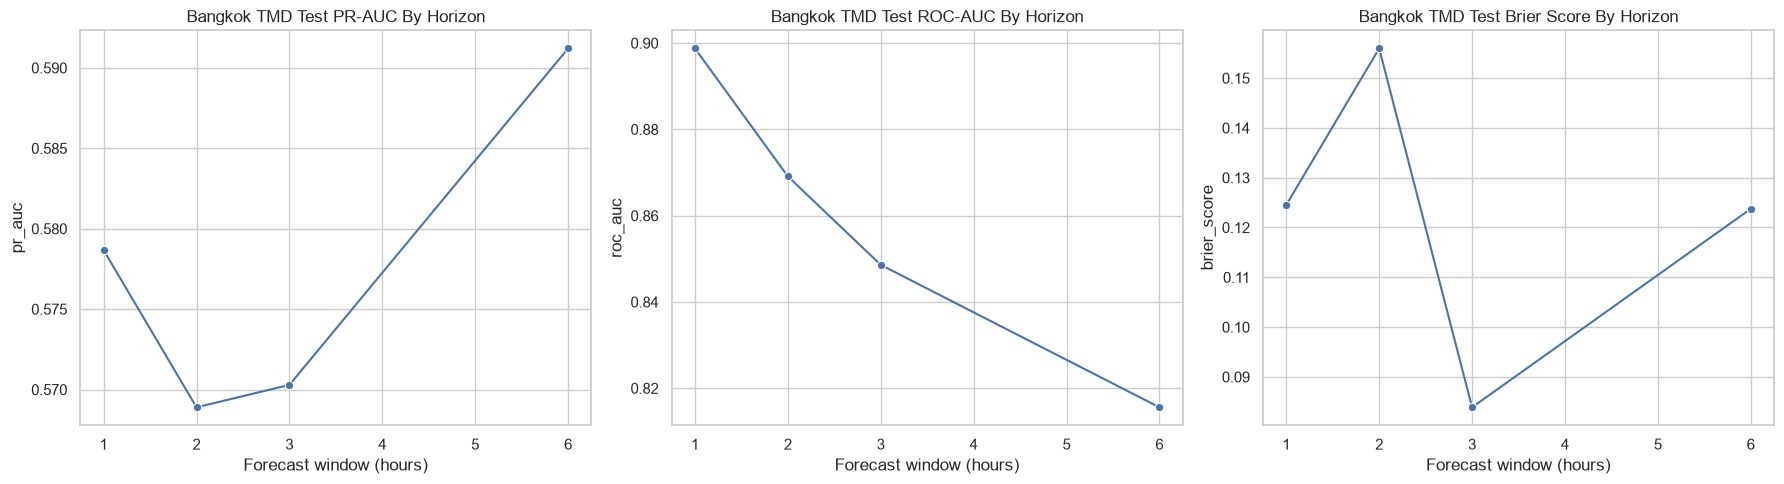

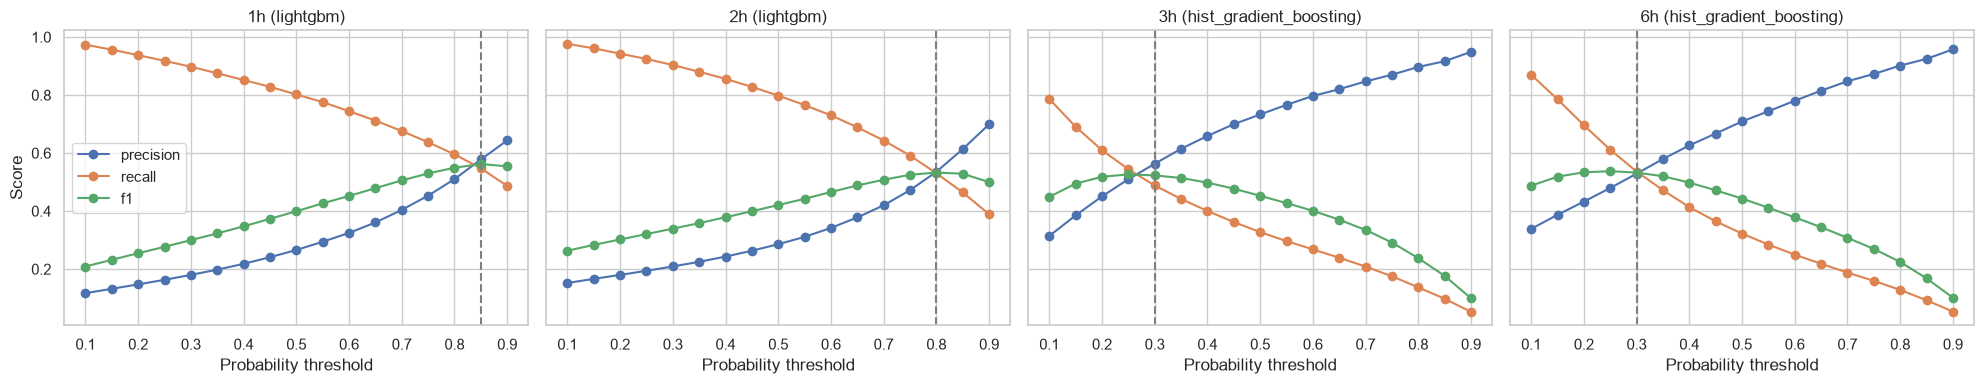

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
test_metrics = all_metrics[all_metrics["split"] == "test"]
sns.lineplot(data=test_metrics, x="horizon_h", y="pr_auc", marker="o", ax=axes[0])
axes[0].set_title("Bangkok TMD Test PR-AUC By Horizon")
sns.lineplot(data=test_metrics, x="horizon_h", y="roc_auc", marker="o", ax=axes[1])
axes[1].set_title("Bangkok TMD Test ROC-AUC By Horizon")
sns.lineplot(data=test_metrics, x="horizon_h", y="brier_score", marker="o", ax=axes[2])
axes[2].set_title("Bangkok TMD Test Brier Score By Horizon")
for ax in axes:
    ax.set_xlabel("Forecast window (hours)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(20, 4), sharey=True)
for ax, horizon in zip(axes, HORIZONS):
    subset = all_threshold_results[
        (all_threshold_results["horizon_h"] == horizon)
        & (all_threshold_results["split"] == "test")
    ]
    ax.plot(subset["probability_threshold"], subset["precision"], marker="o", label="precision")
    ax.plot(subset["probability_threshold"], subset["recall"], marker="o", label="recall")
    ax.plot(subset["probability_threshold"], subset["f1"], marker="o", label="f1")
    ax.axvline(SELECTED_PROBABILITY_THRESHOLDS[horizon], color="grey", linestyle="--")
    ax.set_title(f"{horizon}h ({MODEL_PLAN[horizon]})")
    ax.set_xlabel("Probability threshold")
axes[0].set_ylabel("Score")
axes[0].legend()
plt.tight_layout()
plt.show()

,model,horizon_h,feature,importance,is_neighbor_feature
8,lightgbm,1,max_wind_speed_knot,1084.0000,False
50,lightgbm,1,nearby_wind_speed_mean_now_100km,1017.0000,True
19,lightgbm,1,humidity_change_3h,1008.0000,False
48,lightgbm,1,nearby_humidity_mean_now_100km,982.0000,True
17,lightgbm,1,pressure_hpa_change_3h,977.0000,False
7,lightgbm,1,wind_speed_avg_knot,956.0000,False
15,lightgbm,1,temperature_humidity_index,939.0000,False
12,lightgbm,1,wind_dir_avg_cos,916.0000,False
18,lightgbm,1,pressure_hpa_change_6h,915.0000,False
11,lightgbm,1,wind_dir_avg_sin,909.0000,False


Share of LightGBM split importance coming from 100 km neighbourhood features


is_neighbor_feature,False,True,neighbor_importance_share
horizon_h,,,
1,21605.0000,9395.0000,0.3031
2,21397.0000,9603.0000,0.3098


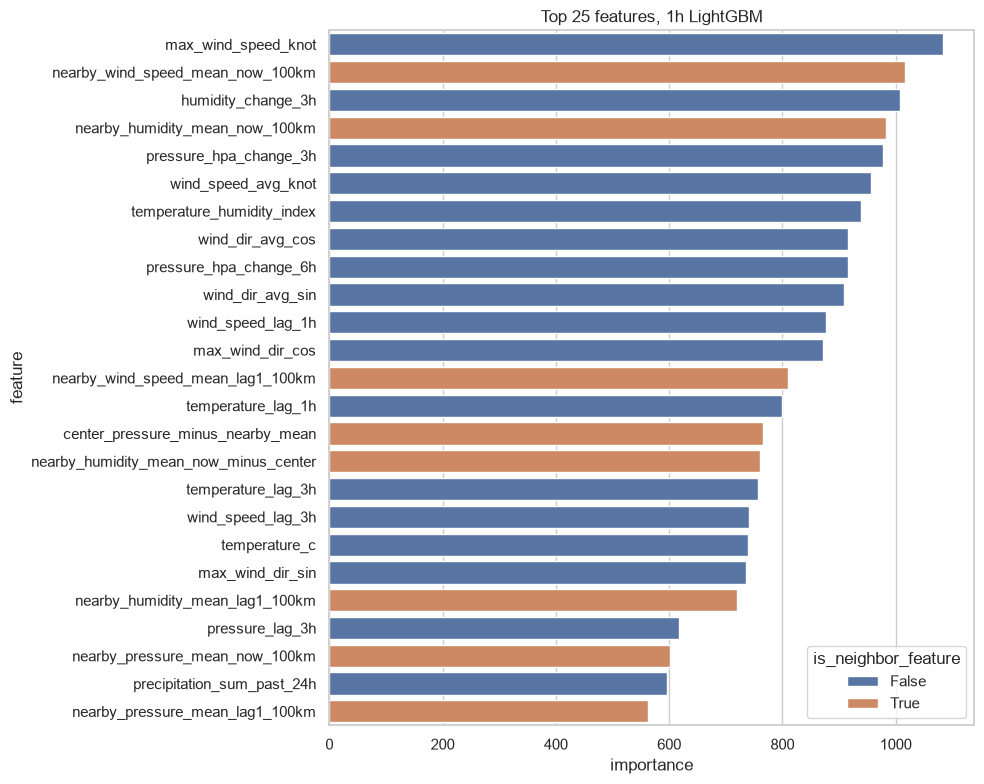

In [13]:
feature_importance = pd.DataFrame(feature_importance_rows)
if not feature_importance.empty:
    top_importance = (
        feature_importance.sort_values(["horizon_h", "importance"], ascending=[True, False])
        .groupby("horizon_h").head(20)
    )
    display(top_importance)

    neighbor_share = (
        feature_importance.groupby(["horizon_h", "is_neighbor_feature"])["importance"].sum()
        .unstack(fill_value=0.0)
        .reindex(columns=[False, True], fill_value=0.0)
    )
    neighbor_share["neighbor_importance_share"] = (
        neighbor_share[True] / neighbor_share.sum(axis=1)
    )
    print("Share of LightGBM split importance coming from 100 km neighbourhood features")
    display(neighbor_share)

    fig, ax = plt.subplots(figsize=(10, 8))
    top_1h = feature_importance[feature_importance["horizon_h"] == 1].nlargest(25, "importance")
    sns.barplot(data=top_1h, y="feature", x="importance",
                hue="is_neighbor_feature", dodge=False, ax=ax)
    ax.set_title("Top 25 features, 1h LightGBM")
    plt.tight_layout()
    plt.show()

## 10. Save Final Models And Results

In [14]:
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for horizon, model in models.items():
    model_name = MODEL_PLAN[horizon]
    threshold = SELECTED_PROBABILITY_THRESHOLDS[horizon]
    path = MODEL_DIR / (
        f"tmd_bkk_rain_any_next_{horizon}h_neighbor_100km_{model_name}"
        f"_prob_threshold_{threshold:g}_rain_threshold_{RAIN_THRESHOLD_MM:g}mm.joblib"
    )
    joblib.dump(model, path)

target_balance.to_csv(MODEL_DIR / "final_4_target_balance.csv", index=False)
all_metrics.to_csv(MODEL_DIR / "final_4_metrics.csv", index=False)
all_threshold_results.to_csv(MODEL_DIR / "final_4_probability_thresholds.csv", index=False)
best_by_f1.to_csv(MODEL_DIR / "final_4_best_thresholds_by_f1.csv", index=False)
selected_threshold_metrics.to_csv(MODEL_DIR / "final_4_selected_threshold_metrics.csv", index=False)
bangkok_threshold_metrics.to_csv(MODEL_DIR / "final_4_bangkok_threshold_metrics.csv", index=False)
if not feature_importance.empty:
    feature_importance.to_csv(MODEL_DIR / "final_4_lightgbm_feature_importance.csv", index=False)

metadata = {
    "table": TABLE_NAME,
    "spatial_table": SPATIAL_TABLE_NAME,
    "region": "bangkok_basin_tmd_stations",
    "region_filter": KEEP_REGION,
    "observation_source": "TMD station rain gauges (ground truth, not NWP output)",
    "target_type": "rain_any_within_next_n_hours",
    "model_plan": MODEL_PLAN,
    "selected_probability_thresholds": SELECTED_PROBABILITY_THRESHOLDS,
    "bangkok_probability_thresholds": BANGKOK_PROBABILITY_THRESHOLDS,
    "threshold_selection": "best F1 on validation split, evaluated once on test",
    "horizons": HORIZONS,
    "rain_threshold_mm": RAIN_THRESHOLD_MM,
    "feature_columns": FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "required_non_null_columns": REQUIRED_NON_NULL_COLUMNS,
    "panel_note": (
        "reindexed to a gap-free hourly grid per station before lags/targets; "
        "negative precipitation nulled rather than clipped; "
        "weather_code and visibility_m left NaN (~32% missing)"
    ),
    "train_end_exclusive": str(train_end),
    "validation_end_exclusive": str(validation_end),
    "rows": int(x_all.shape[0]),
    "stations": int(np.unique(station).size),
    "train_seconds": train_timings,
    "sample_stations": SAMPLE_STATIONS,
    "model_dir": str(MODEL_DIR),
    "target_balance": target_balance.to_dict(orient="records"),
    "metrics": all_metrics.to_dict(orient="records"),
    "best_thresholds_by_f1": best_by_f1.to_dict(orient="records"),
    "selected_threshold_metrics": selected_threshold_metrics.to_dict(orient="records"),
}
(MODEL_DIR / "final_4_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved final 4 models and result CSVs to {MODEL_DIR}")

Saved final 4 models and result CSVs to C:\Users\Brandon\Documents\Phase 1\ML_Model_V2\trained_models\tmd_bkk_rain_any_final_4_neighbor_models
